In [23]:
gold_source = "/home/baptvit/Documents/github/graphrag-on-fhir/evaluations/data/silver/peformance"

In [55]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

all_dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df["consumer_id"] = file.split("/")[-1]
    all_dfs.append(df)


df_silver = pd.concat(all_dfs, ignore_index=True)

In [56]:
df_silver.head()

,Unnamed: 0,experiment_id,timestamp_output_step,full_response,system_promt,input,output,timestamp_search_step,latency_s,query,...,records,caracteres_count,caracteres_count_after_reduce,pass_map_reduce,resource_type,main_keys,user_query,llm_token_limit,strategy_name,consumer_id
0,0,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,2025-02-07 21:15:09,"{'input': ""What's my current medications and h...",\nAs an expert in interpreting Electronic Heal...,What's my current medications and how should I...,"\n\nBased on your medical records, here are yo...",2025-02-07 21:14:56,0.120028,Similarity Search 0-Hop,...,{'Main health record': 'Document Type: History...,8370,8370.0,False,NaN,medications,NaN,128000,SimilaritySearch0HopStrategy,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...
1,0,Q8:gpt-4o-2024-08-06:similarity_search_0_hop,2025-02-07 21:17:39,{'input': 'Can you summarize my immunization h...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my immunization history ?,"\n\nBased on your EHR records, I can provide a...",2025-02-07 21:17:30,0.067757,Similarity Search 0-Hop,...,{'Main health record': 'Immunization Status: c...,4400,4400.0,False,NaN,immunizations vaccinations shots,NaN,128000,SimilaritySearch0HopStrategy,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...
2,0,Q5:gpt-4o-2024-08-06:similarity_search_0_hop,2025-02-07 21:16:37,{'input': 'Can you summarize my care plan hist...,\nAs an expert in interpreting Electronic Heal...,Can you summarize my care plan history ?,"\n\nBased on your health records, I can provid...",2025-02-07 21:16:27,0.062473,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: CareTea...,2544,2544.0,False,NaN,care plan treatment plan management plan,NaN,128000,SimilaritySearch0HopStrategy,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...
3,0,Q4:gpt-4o-2024-08-06:similarity_search_0_hop,2025-02-07 21:16:18,{'input': 'What are my recent laboratory value...,\nAs an expert in interpreting Electronic Heal...,"What are my recent laboratory values, what do ...",\n\nBased on the laboratory results retrieved ...,2025-02-07 21:15:54,0.074059,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: Diagnos...,91954,91954.0,False,NaN,lab results blood tests laboratory values,NaN,128000,SimilaritySearch0HopStrategy,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...
4,0,Q6:gpt-4o-2024-08-06:similarity_search_0_hop,2025-02-07 21:17:06,{'input': 'Can you provide a breakdown of my m...,\nAs an expert in interpreting Electronic Heal...,Can you provide a breakdown of my medical bills ?,\n\nBased on the retrieved medical billing rec...,2025-02-07 21:16:45,0.073021,Similarity Search 0-Hop,...,{'Main health record': 'Resource Type: Explana...,72664,72664.0,False,NaN,billing charges payment insurance claims,NaN,128000,SimilaritySearch0HopStrategy,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...


In [57]:
df_silver.columns

Index(['Unnamed: 0', 'experiment_id', 'timestamp_output_step', 'full_response',
       'system_promt', 'input', 'output', 'timestamp_search_step', 'latency_s',
       'query', 'similarity_threshold', 'k', 'embedding_model',
       'timestamp_token_step', 'total_cost', 'total_tokens',
       'successful_requests', 'completion_tokens', 'prompt_tokens',
       'total_time', 'timestamp_tool_step', 'records', 'caracteres_count',
       'caracteres_count_after_reduce', 'pass_map_reduce', 'resource_type',
       'main_keys', 'user_query', 'llm_token_limit', 'strategy_name',
       'consumer_id'],
      dtype='object')

In [58]:
df = df_silver[
    ["consumer_id", "experiment_id", "strategy_name", "total_time", "total_tokens"]
]

In [59]:
df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)

/tmp/ipykernel_48537/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)
/tmp/ipykernel_48537/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["question", "model", "search_type"]] = df["experiment_id"].str.split(":", expand=True)
/tmp/ipykernel_48537/369627844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [60]:
df = df[["consumer_id", "model", "search_type", "question", "total_time", "total_tokens"]]

In [61]:
df = df.replace("anthropic.claude-v3-5-sonnet-v2", "anthropic.claude-v3-opus")
df = df.replace("gpt-4o-2024-11-20", "gpt-4o-2024-08-06")

In [70]:
dict_map = {
    "lexical_search_0_hop": "L0",
    "lexical_search_1_hop": "L1",
    "lexical_search_2_hop": "L
    2",
    "similarity_search_0_hop": "S0",
    "similarity_search_1_hop": "S1",
}
df = df.replace({"search_type": dict_map})

In [71]:
df.head().to_dict()

{'consumer_id': {209: 'Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9153d023d-gemini-1.5-pro.csv',
  324: 'Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f6bbce1a32-anthropic.claude-v3-opus.csv',
  323: 'Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f6bbce1a32-anthropic.claude-v3-opus.csv',
  322: 'Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f6bbce1a32-anthropic.claude-v3-opus.csv',
  321: 'Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f6bbce1a32-anthropic.claude-v3-opus.csv'},
 'model': {209: 'gemini-1.5-pro',
  324: 'anthropic.claude-v3-opus',
  323: 'anthropic.claude-v3-opus',
  322: 'anthropic.claude-v3-opus',
  321: 'anthropic.claude-v3-opus'},
 'search_type': {209: 'L0', 324: 'L0', 323: 'L0', 322: 'L0', 321: 'L0'},
 'question': {209: 'Q3', 324: 'Q5', 323: 'Q2', 322: 'Q7', 321: 'Q1'},
 'total_time': {209: 13.671225786209106,
  324: 17.130547523498535,
  323: 13.519910335540771,
  322: 33.01967978477478,
  321: 63.03048920631409},
 'total_tokens': {209: 5968, 324: 3681, 323: 2449, 322

In [72]:
# Basic statistical analysis
statistics = df[["total_time", "total_tokens"]].describe()

# Adding custom percentiles
percentiles = df[["total_time", "total_tokens"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
percentiles.columns = ["5%", "25%", "50%", "75%", "95%"]

# Calculating variance
variance = df[["total_time", "total_tokens"]].var()

# Calculating additional statistics (if needed)
skewness = df[["total_time", "total_tokens"]].skew()
kurtosis = df[["total_time", "total_tokens"]].kurt()

# Combine results into a single DataFrame for better overview
detailed_stats = pd.concat(
    [
        statistics.T,
        percentiles,
        variance.rename("variance"),
        skewness.rename("skewness"),
        kurtosis.rename("kurtosis"),
    ],
    axis=1,
)

# Display the results
print(detailed_stats)

              count          mean            std         min          25%  \
total_time    463.0     32.191284      41.828529    3.935503    12.480386   
total_tokens  463.0  51030.781857  105946.547696  999.000000  4363.000000   

                       50%           75%           max           5%  \
total_time       20.506293     36.338063  4.739152e+02     6.127661   
total_tokens  13733.000000  52105.000000  1.136609e+06  1355.600000   

                      25%           50%           75%            95%  \
total_time      12.480386     20.506293     36.338063      94.921751   
total_tokens  4363.000000  13733.000000  52105.000000  184988.700000   

                  variance  skewness   kurtosis  
total_time    1.749626e+03  5.423688  41.723148  
total_tokens  1.122467e+10  5.467490  40.830375  


In [73]:
df[["search_type", "total_time", "total_tokens"]].describe()

,total_time,total_tokens
count,463.000000,4.630000e+02
mean,32.191284,5.103078e+04
std,41.828529,1.059465e+05
min,3.935503,9.990000e+02
25%,12.480386,4.363000e+03
50%,20.506293,1.373300e+04
75%,36.338063,5.210500e+04
max,473.915154,1.136609e+06


# Per search type

In [74]:
analysis = (
    df.groupby("search_type")
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .reset_index()
)

analysis

,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,L0,24.193184,22.173186,4.058216,11.861983,17.050957,26.078774,123.374901,15486.535714,21638.624149,999,2959.50,6359.0,20016.50,128507
1,L1,38.259596,33.024530,4.094568,16.200147,27.318351,47.645916,171.892427,69680.196429,83672.042130,1005,8366.25,34678.0,111396.75,395997
2,S0,19.794283,16.231214,3.935503,10.595384,15.353500,24.401742,123.820415,19414.857143,37933.155706,1034,3426.00,5801.5,15357.75,279085
3,S1,32.394912,26.691180,4.145251,13.947763,26.279393,39.655891,151.662111,76204.812500,118186.640535,1032,13540.50,40260.5,105512.50,786994
4,S2,137.644237,153.311594,4.342664,25.586983,62.511771,268.365401,473.915154,225278.333333,361318.840297,1001,13612.00,18859.0,342561.50,1136609


In [75]:
analysis.to_dict()

{'search_type': {0: 'L0', 1: 'L1', 2: 'S0', 3: 'S1', 4: 'S2'},
 'total_time_mean': {0: 24.193183909569466,
  1: 38.25959584968431,
  2: 19.794283072863305,
  3: 32.39491174902235,
  4: 137.64423675537108},
 'total_time_std': {0: 22.173185799285758,
  1: 33.024529920689204,
  2: 16.231213909658845,
  3: 26.69117956110823,
  4: 153.31159447192306},
 'total_time_min': {0: 4.058215618133545,
  1: 4.094568252563477,
  2: 3.935502767562866,
  3: 4.145251035690308,
  4: 4.342663764953613},
 'total_time_25th': {0: 11.861982822418213,
  1: 16.200147449970245,
  2: 10.595384180545807,
  3: 13.947763442993164,
  4: 25.58698308467865},
 'total_time_median': {0: 17.05095672607422,
  1: 27.318350553512573,
  2: 15.3534996509552,
  3: 26.279393076896667,
  4: 62.5117712020874},
 'total_time_75th': {0: 26.07877373695374,
  1: 47.64591586589813,
  2: 24.40174174308777,
  3: 39.655891478061676,
  4: 268.36540126800537},
 'total_time_max': {0: 123.37490105628969,
  1: 171.892427444458,
  2: 123.820415019

# Per model

In [84]:
analysis_model = (
    df.groupby(by=["model", "search_type"])
    .agg(
        total_time_mean=("total_time", "mean"),
        total_time_std=("total_time", "std"),
        total_time_min=("total_time", "min"),
        total_time_25th=("total_time", lambda x: x.quantile(0.25)),
        total_time_median=("total_time", "median"),
        total_time_75th=("total_time", lambda x: x.quantile(0.75)),
        total_time_max=("total_time", "max"),
        total_tokens_mean=("total_tokens", "mean"),
        total_tokens_std=("total_tokens", "std"),
        total_tokens_min=("total_tokens", "min"),
        total_tokens_25th=("total_tokens", lambda x: x.quantile(0.25)),
        total_tokens_median=("total_tokens", "median"),
        total_tokens_75th=("total_tokens", lambda x: x.quantile(0.75)),
        total_tokens_max=("total_tokens", "max"),
    )
    .reset_index()
)

analysis_model

,model,search_type,total_time_mean,total_time_std,total_time_min,total_time_25th,total_time_median,total_time_75th,total_time_max,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_25th,total_tokens_median,total_tokens_75th,total_tokens_max
0,anthropic.claude-v3-opus,L0,35.775512,20.247248,13.519910,19.072612,32.021136,42.517370,88.765707,18295.187500,21870.824337,2449,4479.75,7158.0,22714.25,82372
1,anthropic.claude-v3-opus,L1,41.272495,24.267151,12.408495,22.008447,36.664315,51.621989,133.773197,65610.187500,67097.928375,2459,9629.50,40098.5,91035.75,203931
2,anthropic.claude-v3-opus,S0,30.533772,15.279252,12.961030,19.893383,25.901163,34.974456,67.940261,15557.968750,21263.344325,2235,4560.50,8226.0,15574.75,106081
3,anthropic.claude-v3-opus,S1,40.589348,26.942269,13.349797,24.060236,33.640069,48.253360,130.619279,61885.062500,58085.542125,2247,16079.00,33347.0,112383.00,189081
4,gemini-1.5-pro,L0,22.535266,29.310617,4.058216,8.757763,12.710777,20.123198,123.374901,13479.025000,18994.142428,999,2490.25,5414.0,14449.75,81662
5,gemini-1.5-pro,L1,49.035484,46.239278,4.094568,10.297751,25.453432,83.343365,171.892427,84921.750000,113034.301044,1005,9088.75,28991.0,115731.75,395997
6,gemini-1.5-pro,S0,15.107050,19.358590,3.935503,7.107362,10.680835,15.469543,123.820415,25491.625000,53732.956931,1034,2821.00,4814.5,15810.50,279085
7,gemini-1.5-pro,S1,32.024337,34.679894,4.145251,8.843543,18.015841,40.224348,151.662111,106687.850000,181645.923993,1032,12721.75,34933.5,87547.50,786994
8,gemini-1.5-pro,S2,137.644237,153.311594,4.342664,25.586983,62.511771,268.365401,473.915154,225278.333333,361318.840297,1001,13612.00,18859.0,342561.50,1136609
9,gpt-4o-2024-08-06,L0,16.585239,6.487299,6.107110,12.317318,16.686578,19.892133,34.973845,15247.125000,24103.922736,1068,2659.75,5127.5,19343.00,128507


In [85]:
df = df.sort_values(by=["search_type"], ascending=True)

/tmp/ipykernel_48537/1037350104.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_48537/1037350104.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)


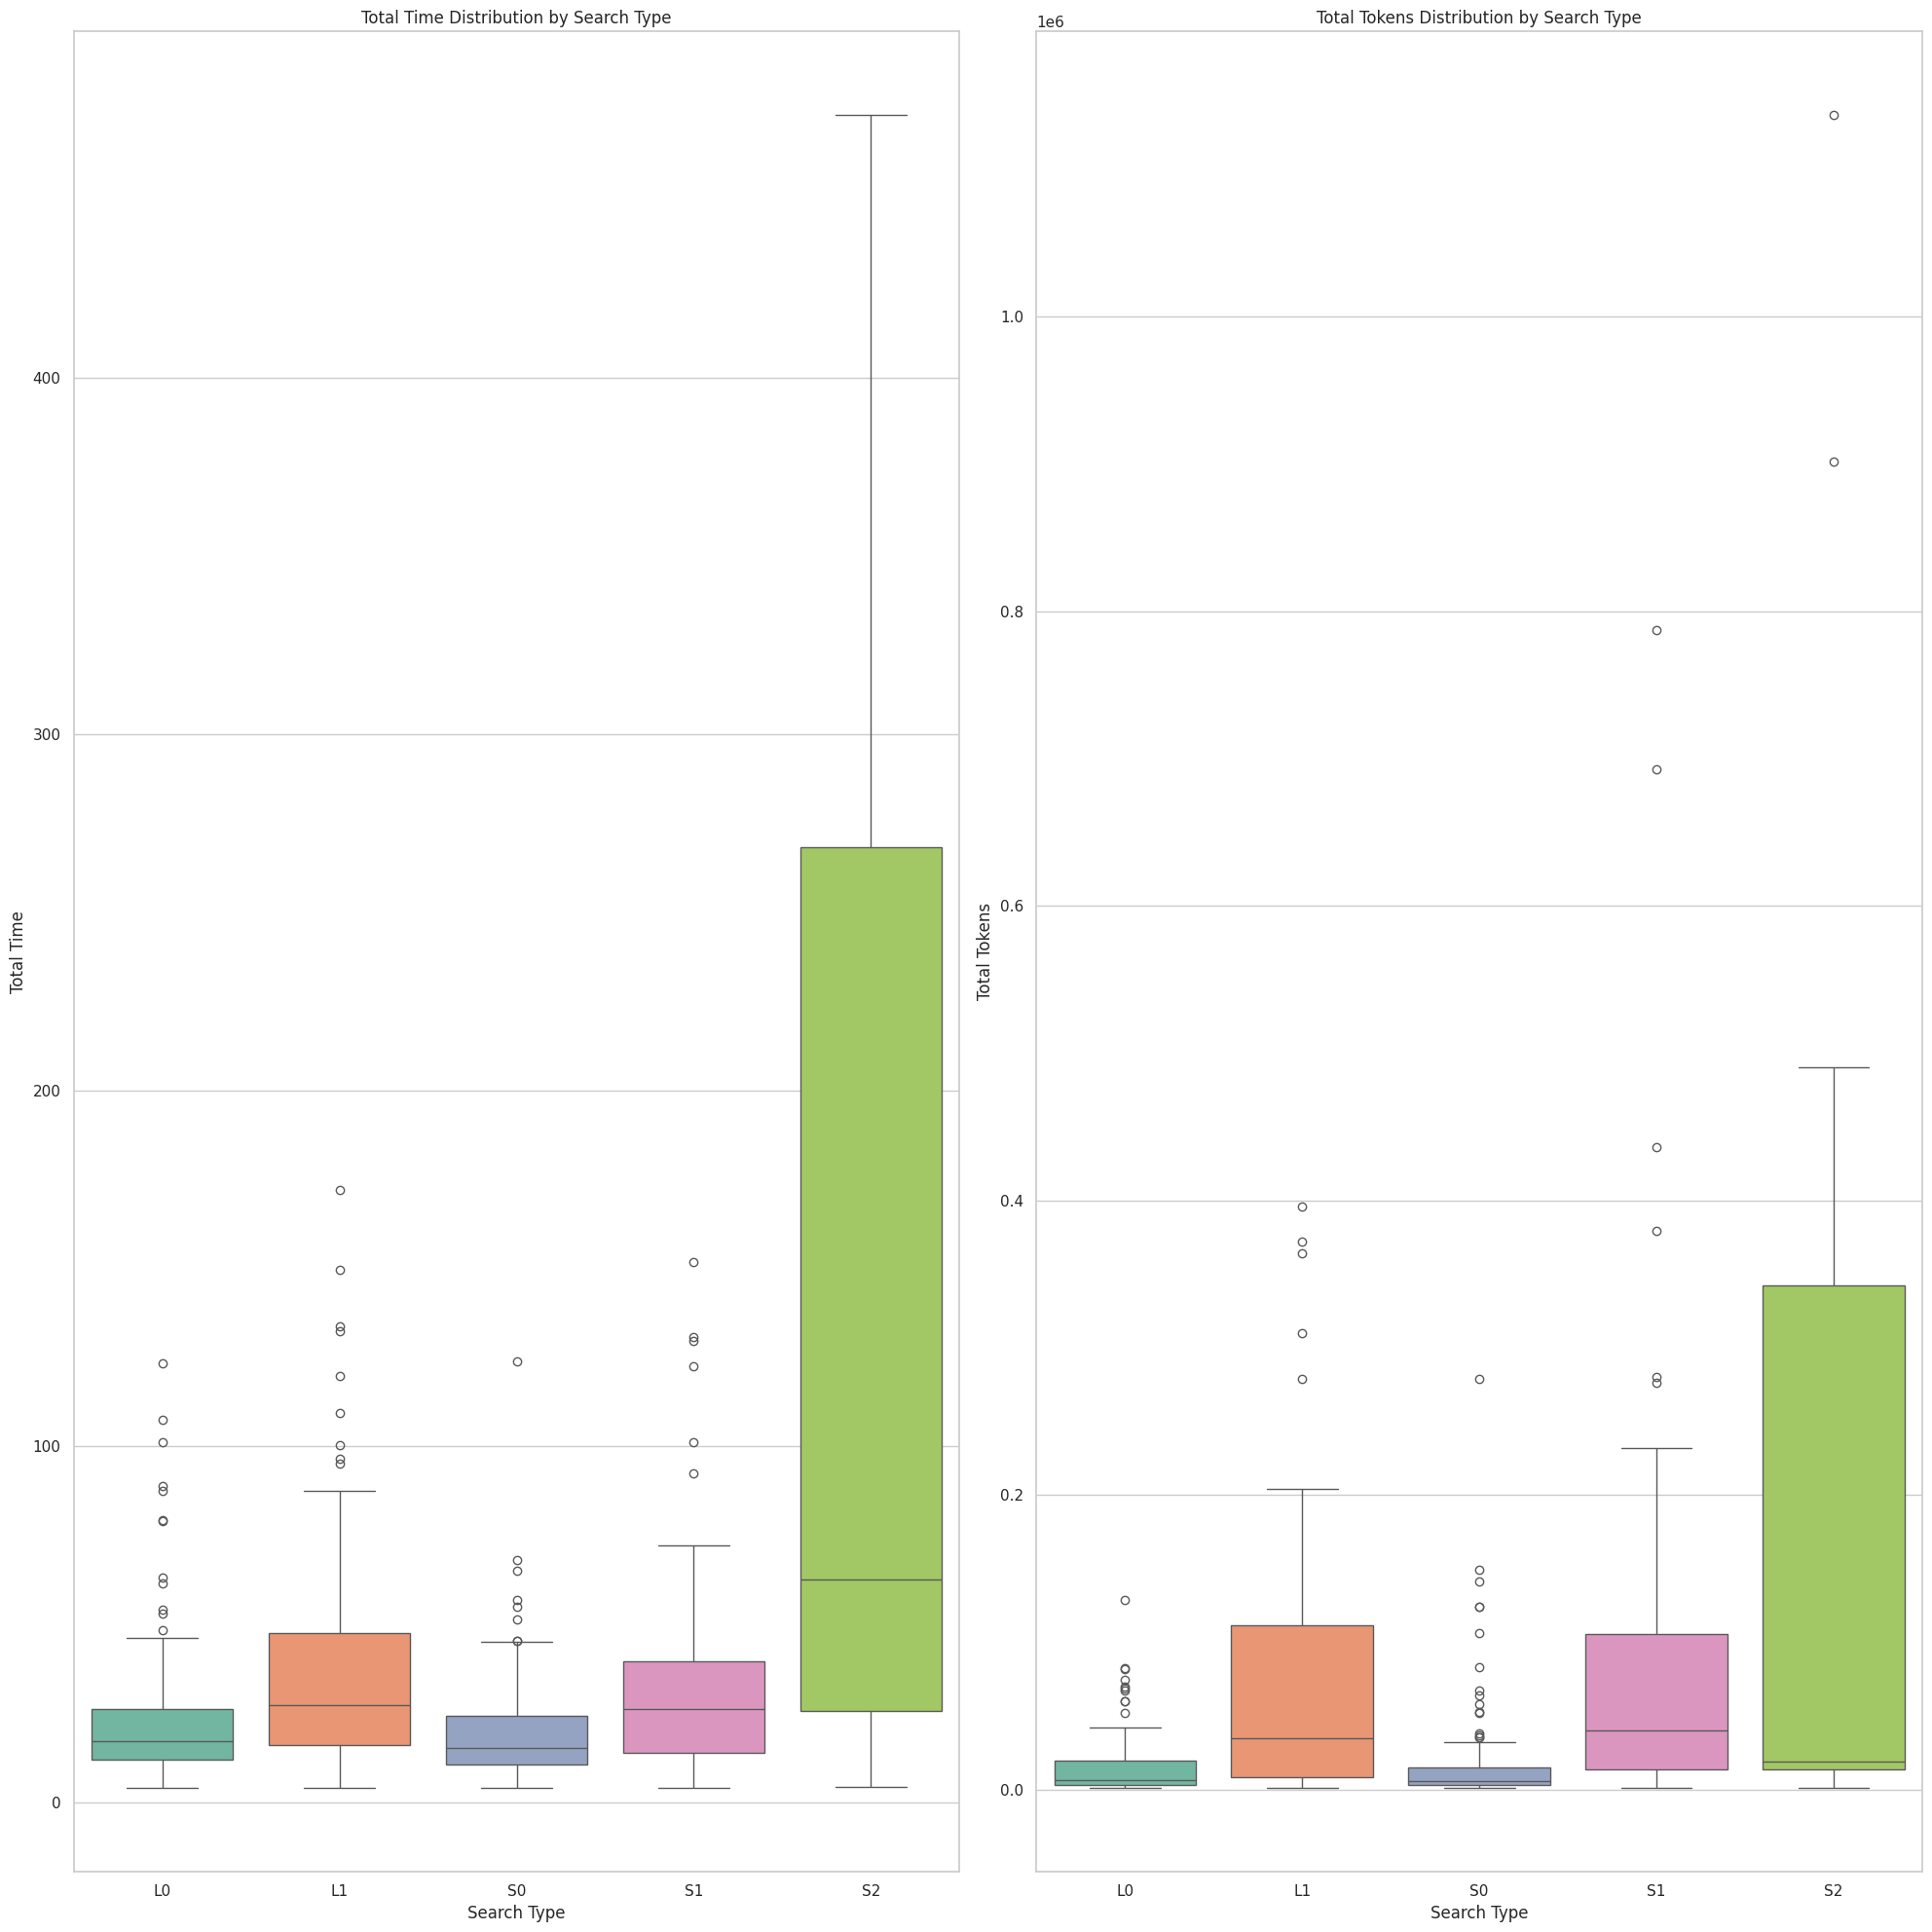

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", legend=False)
plt.title("Total Time Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Time")
plt.tight_layout()
# plt.xticks([])

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", legend=False)
plt.title("Total Tokens Distribution by Search Type")
plt.xlabel("Search Type")
plt.ylabel("Total Tokens")
# plt.legend(['Lexical Search', 'Similarity Search'], loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=True, ncol=5)

plt.tight_layout()

plt.show()

## By model

Boxplots for model:  gemini-1.5-pro


/tmp/ipykernel_48537/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_48537/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


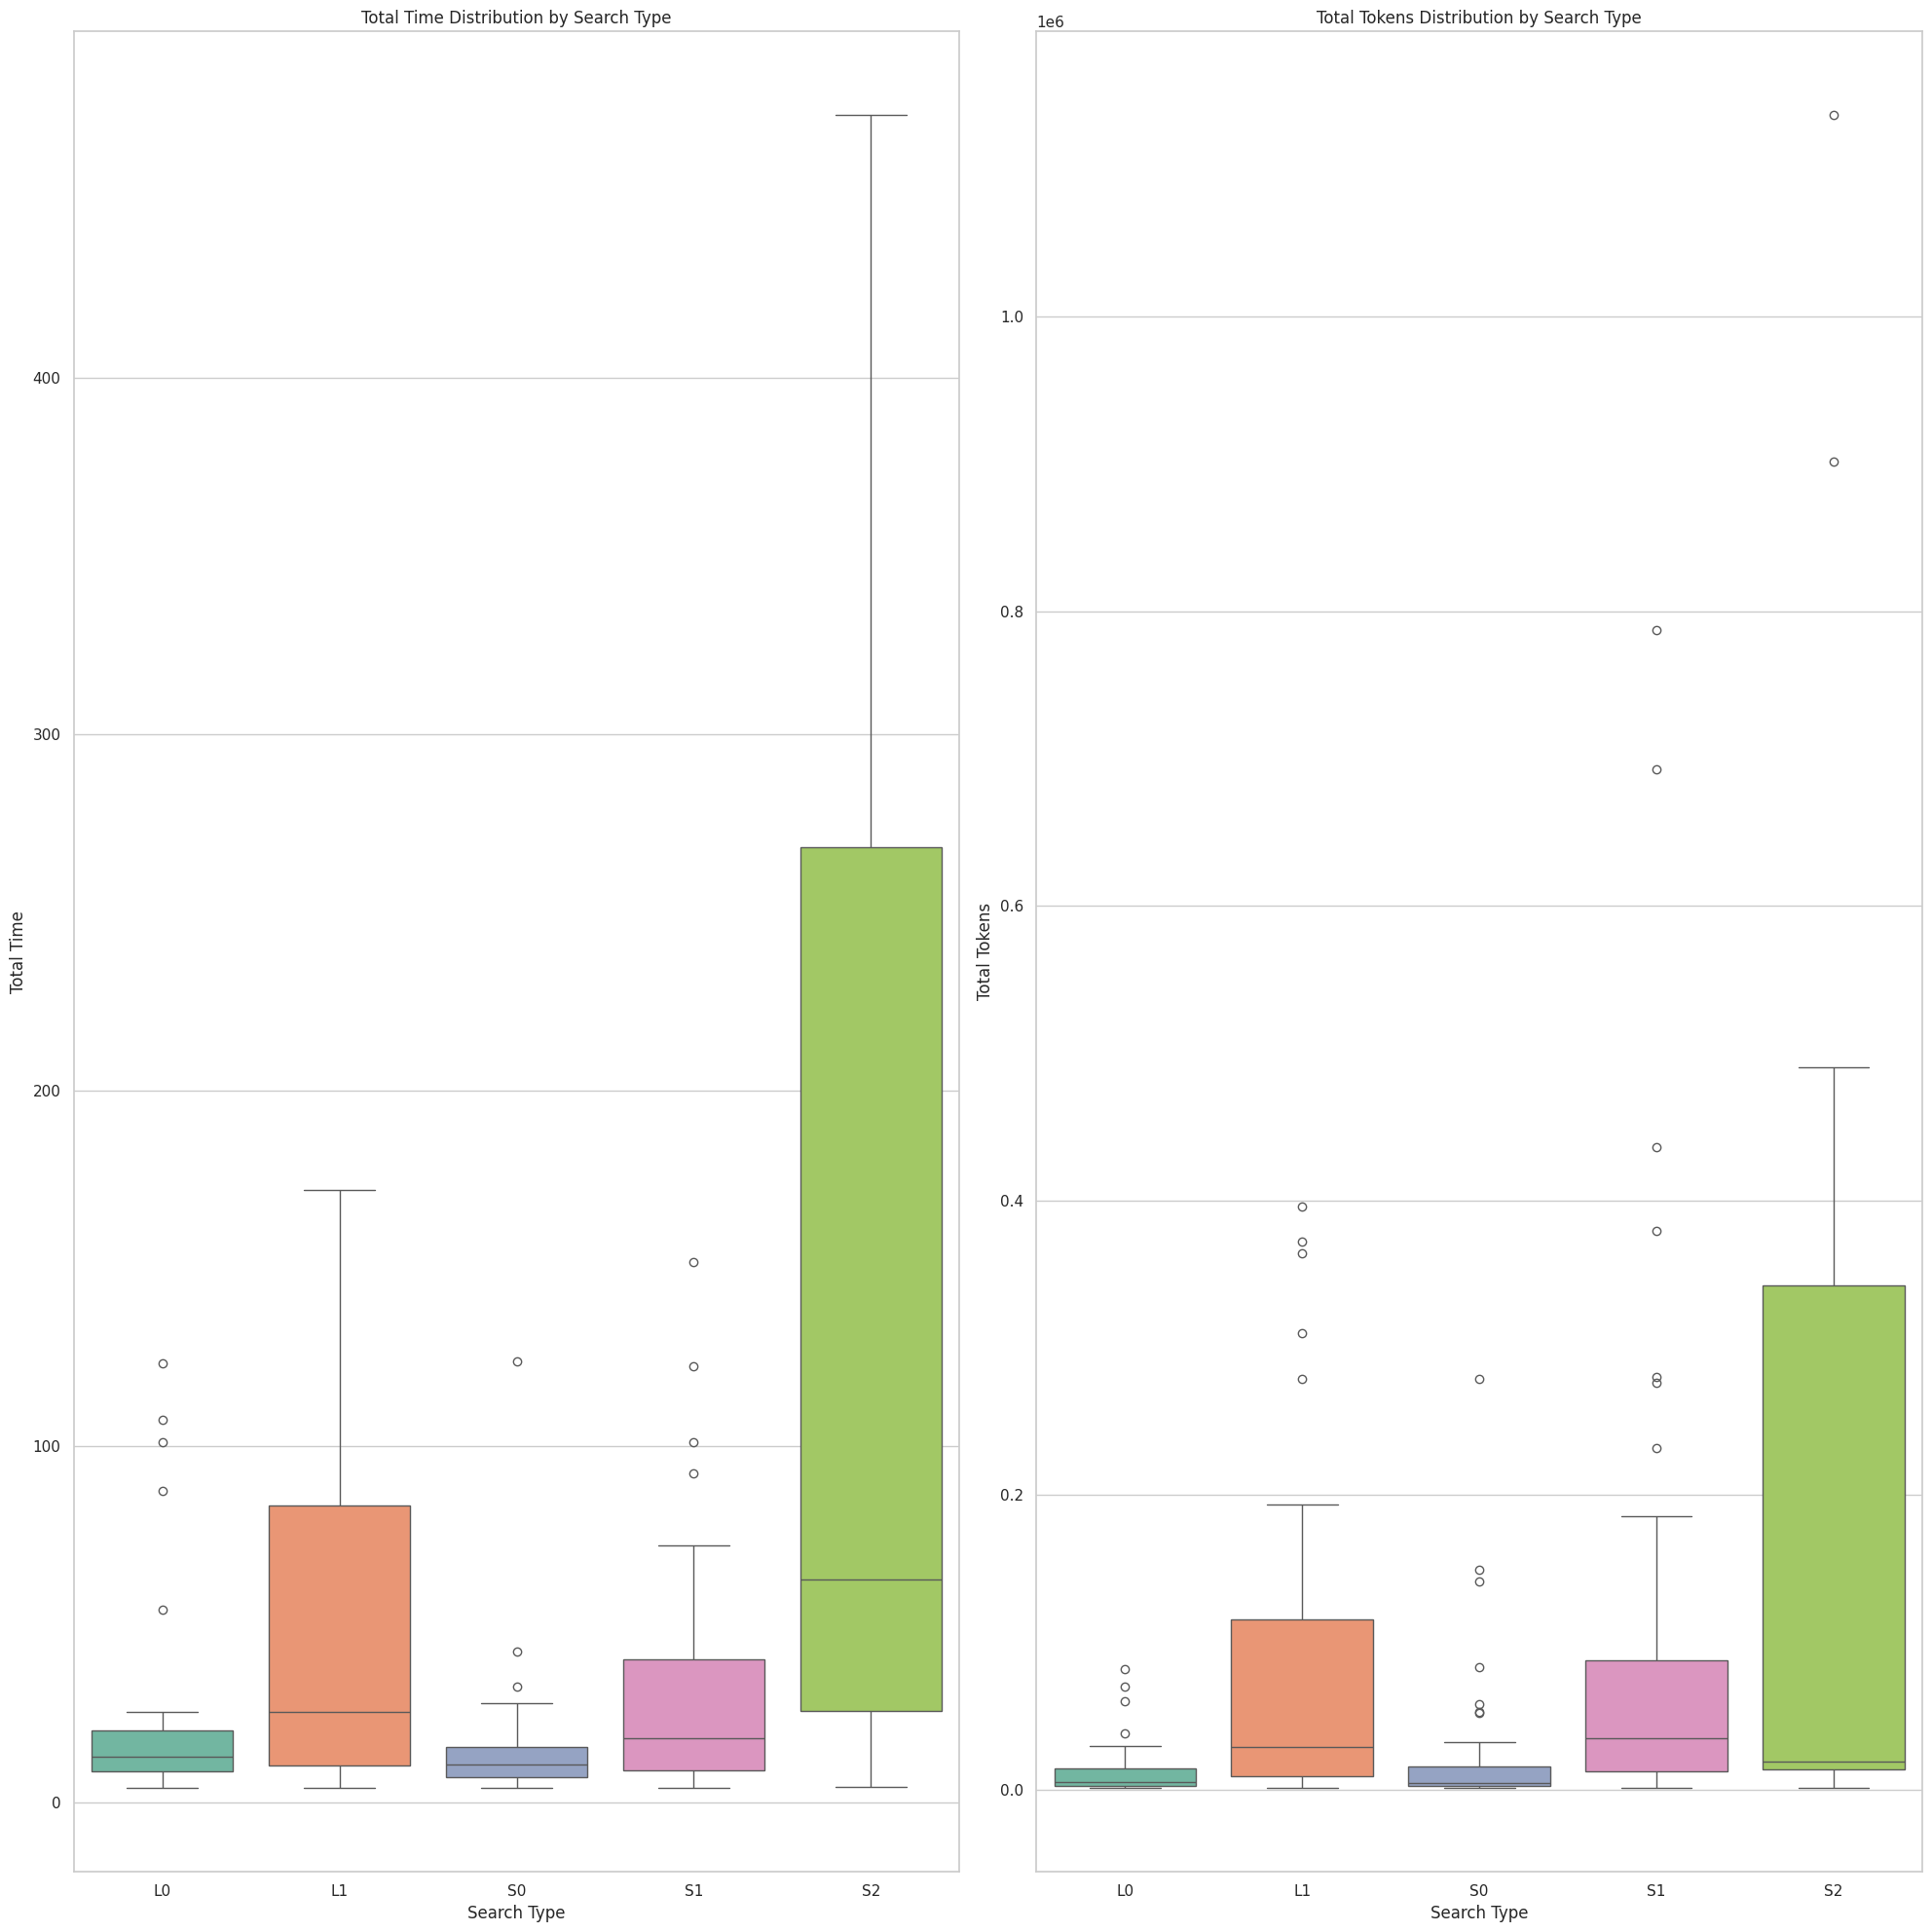

Boxplots for model:  gpt-4o-2024-08-06


/tmp/ipykernel_48537/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_48537/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


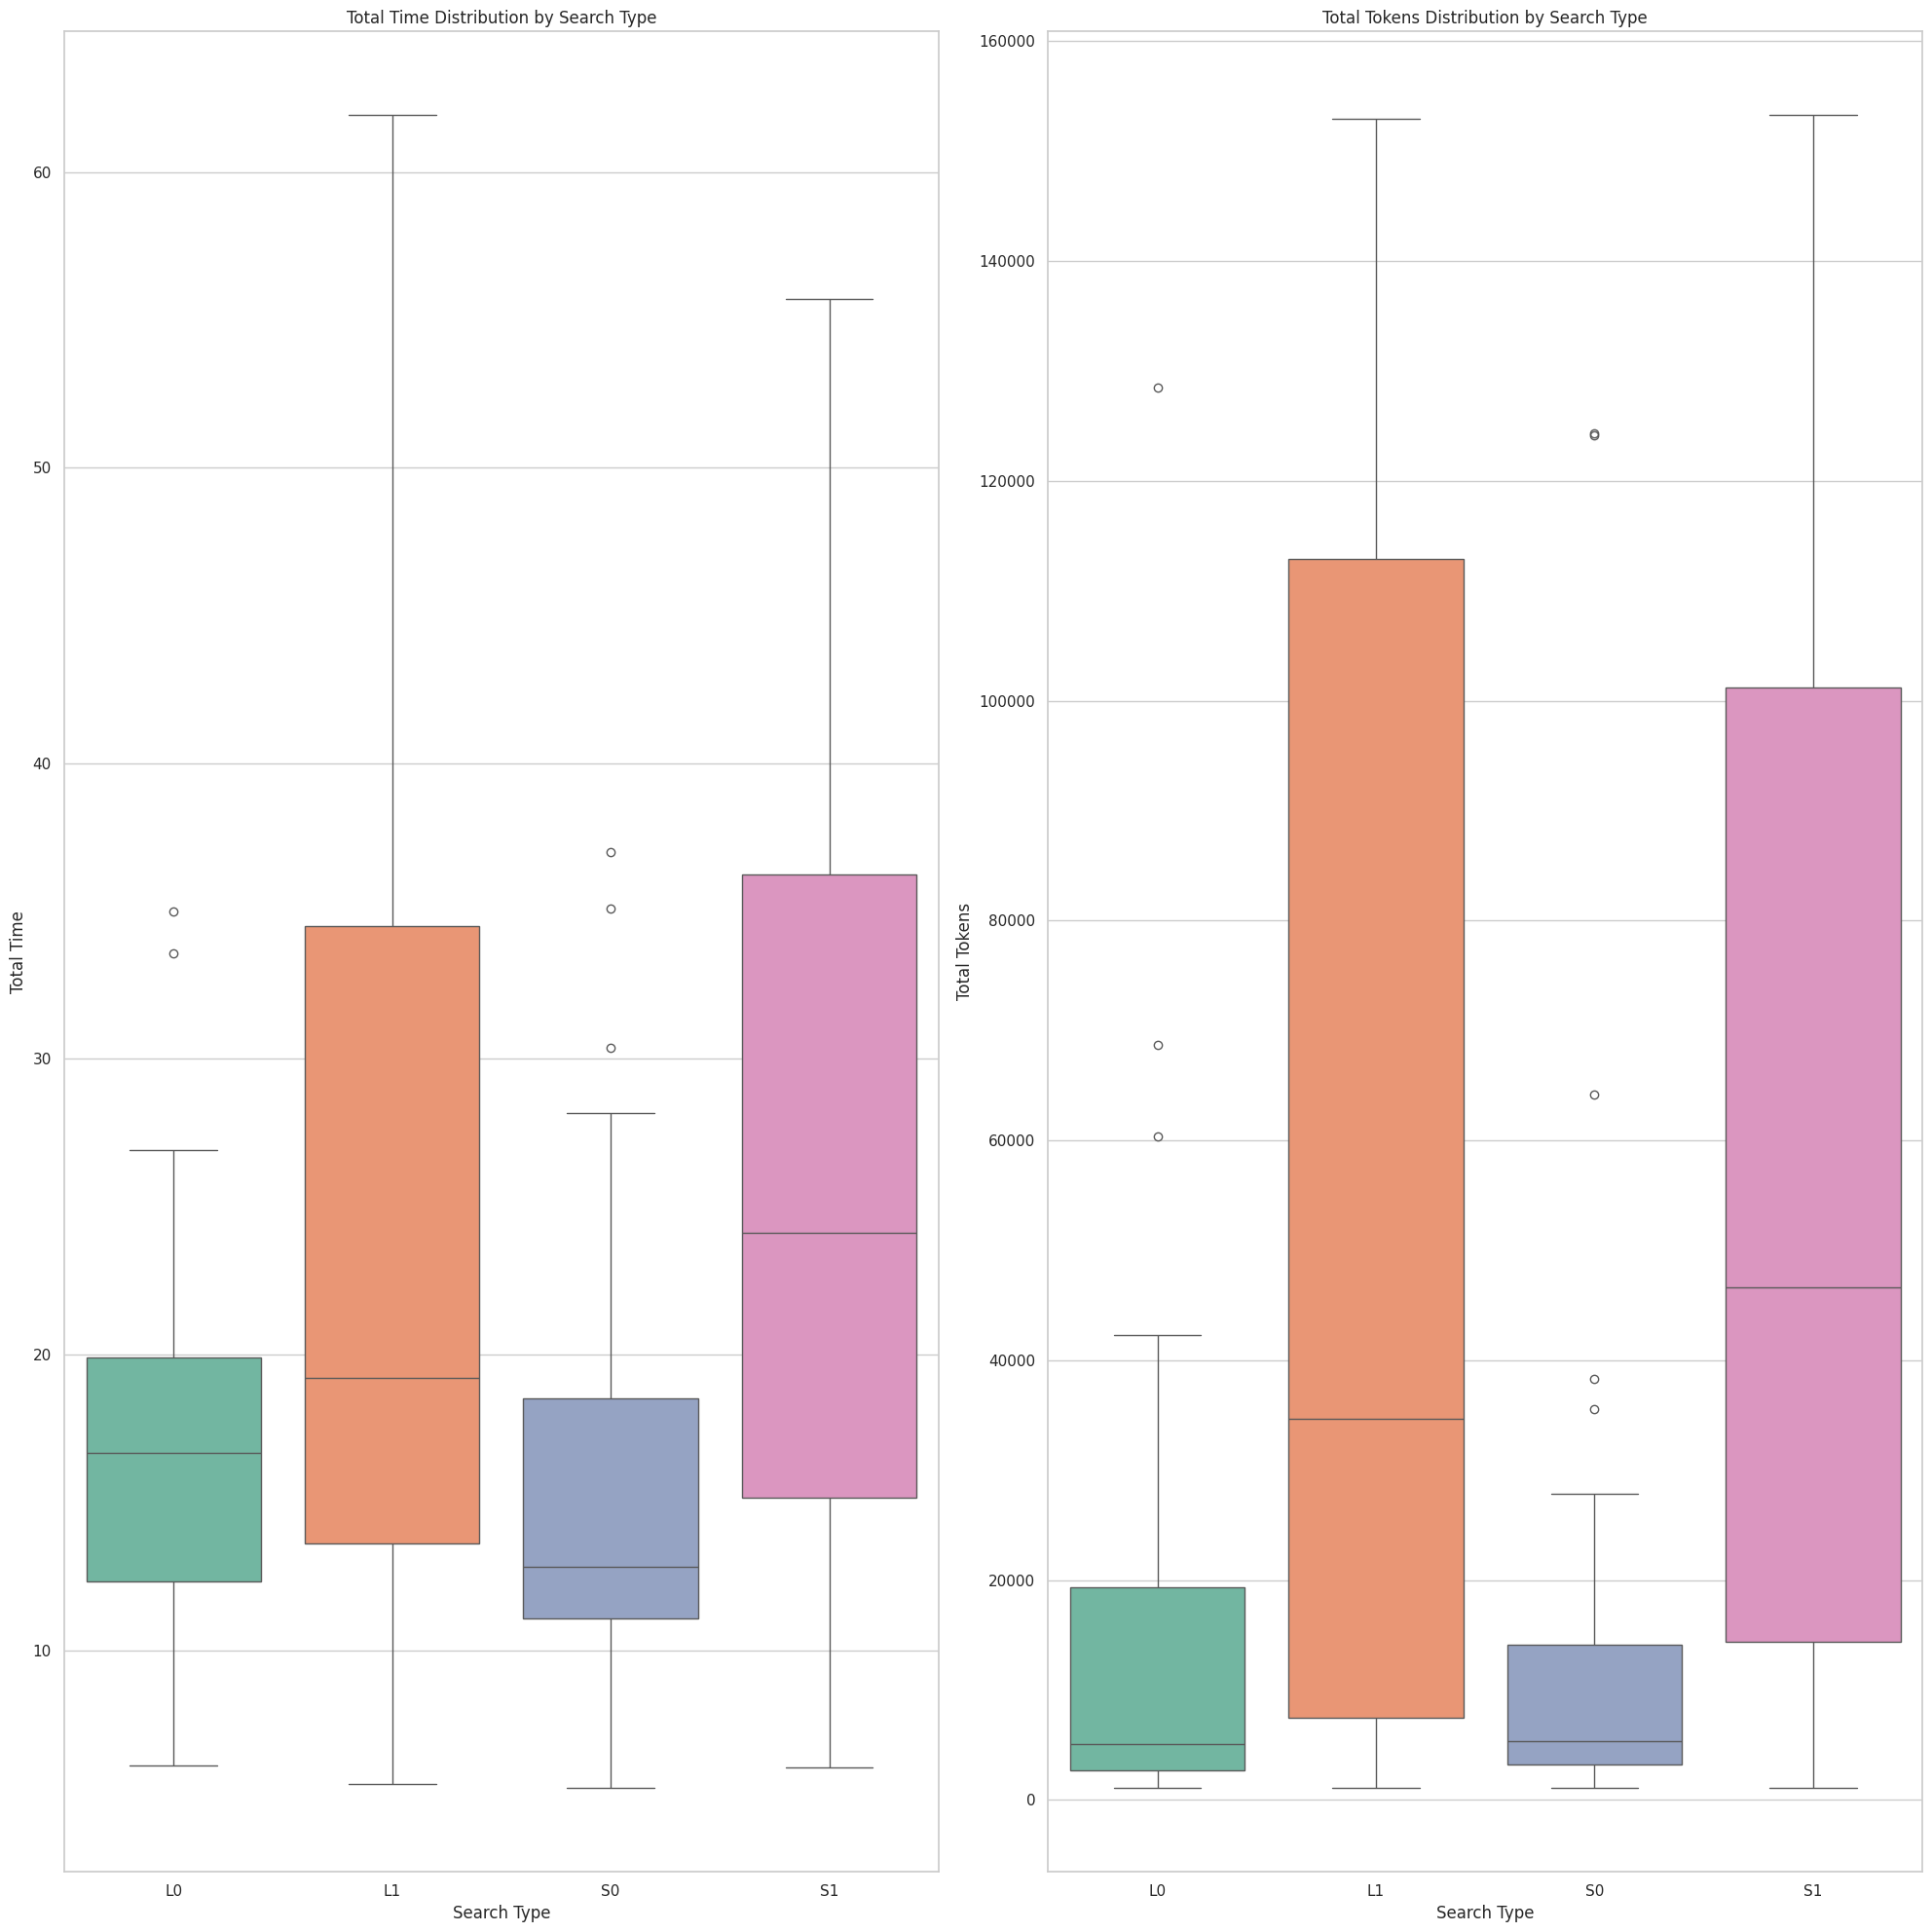

Boxplots for model:  anthropic.claude-v3-opus


/tmp/ipykernel_48537/3243656657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
/tmp/ipykernel_48537/3243656657.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)


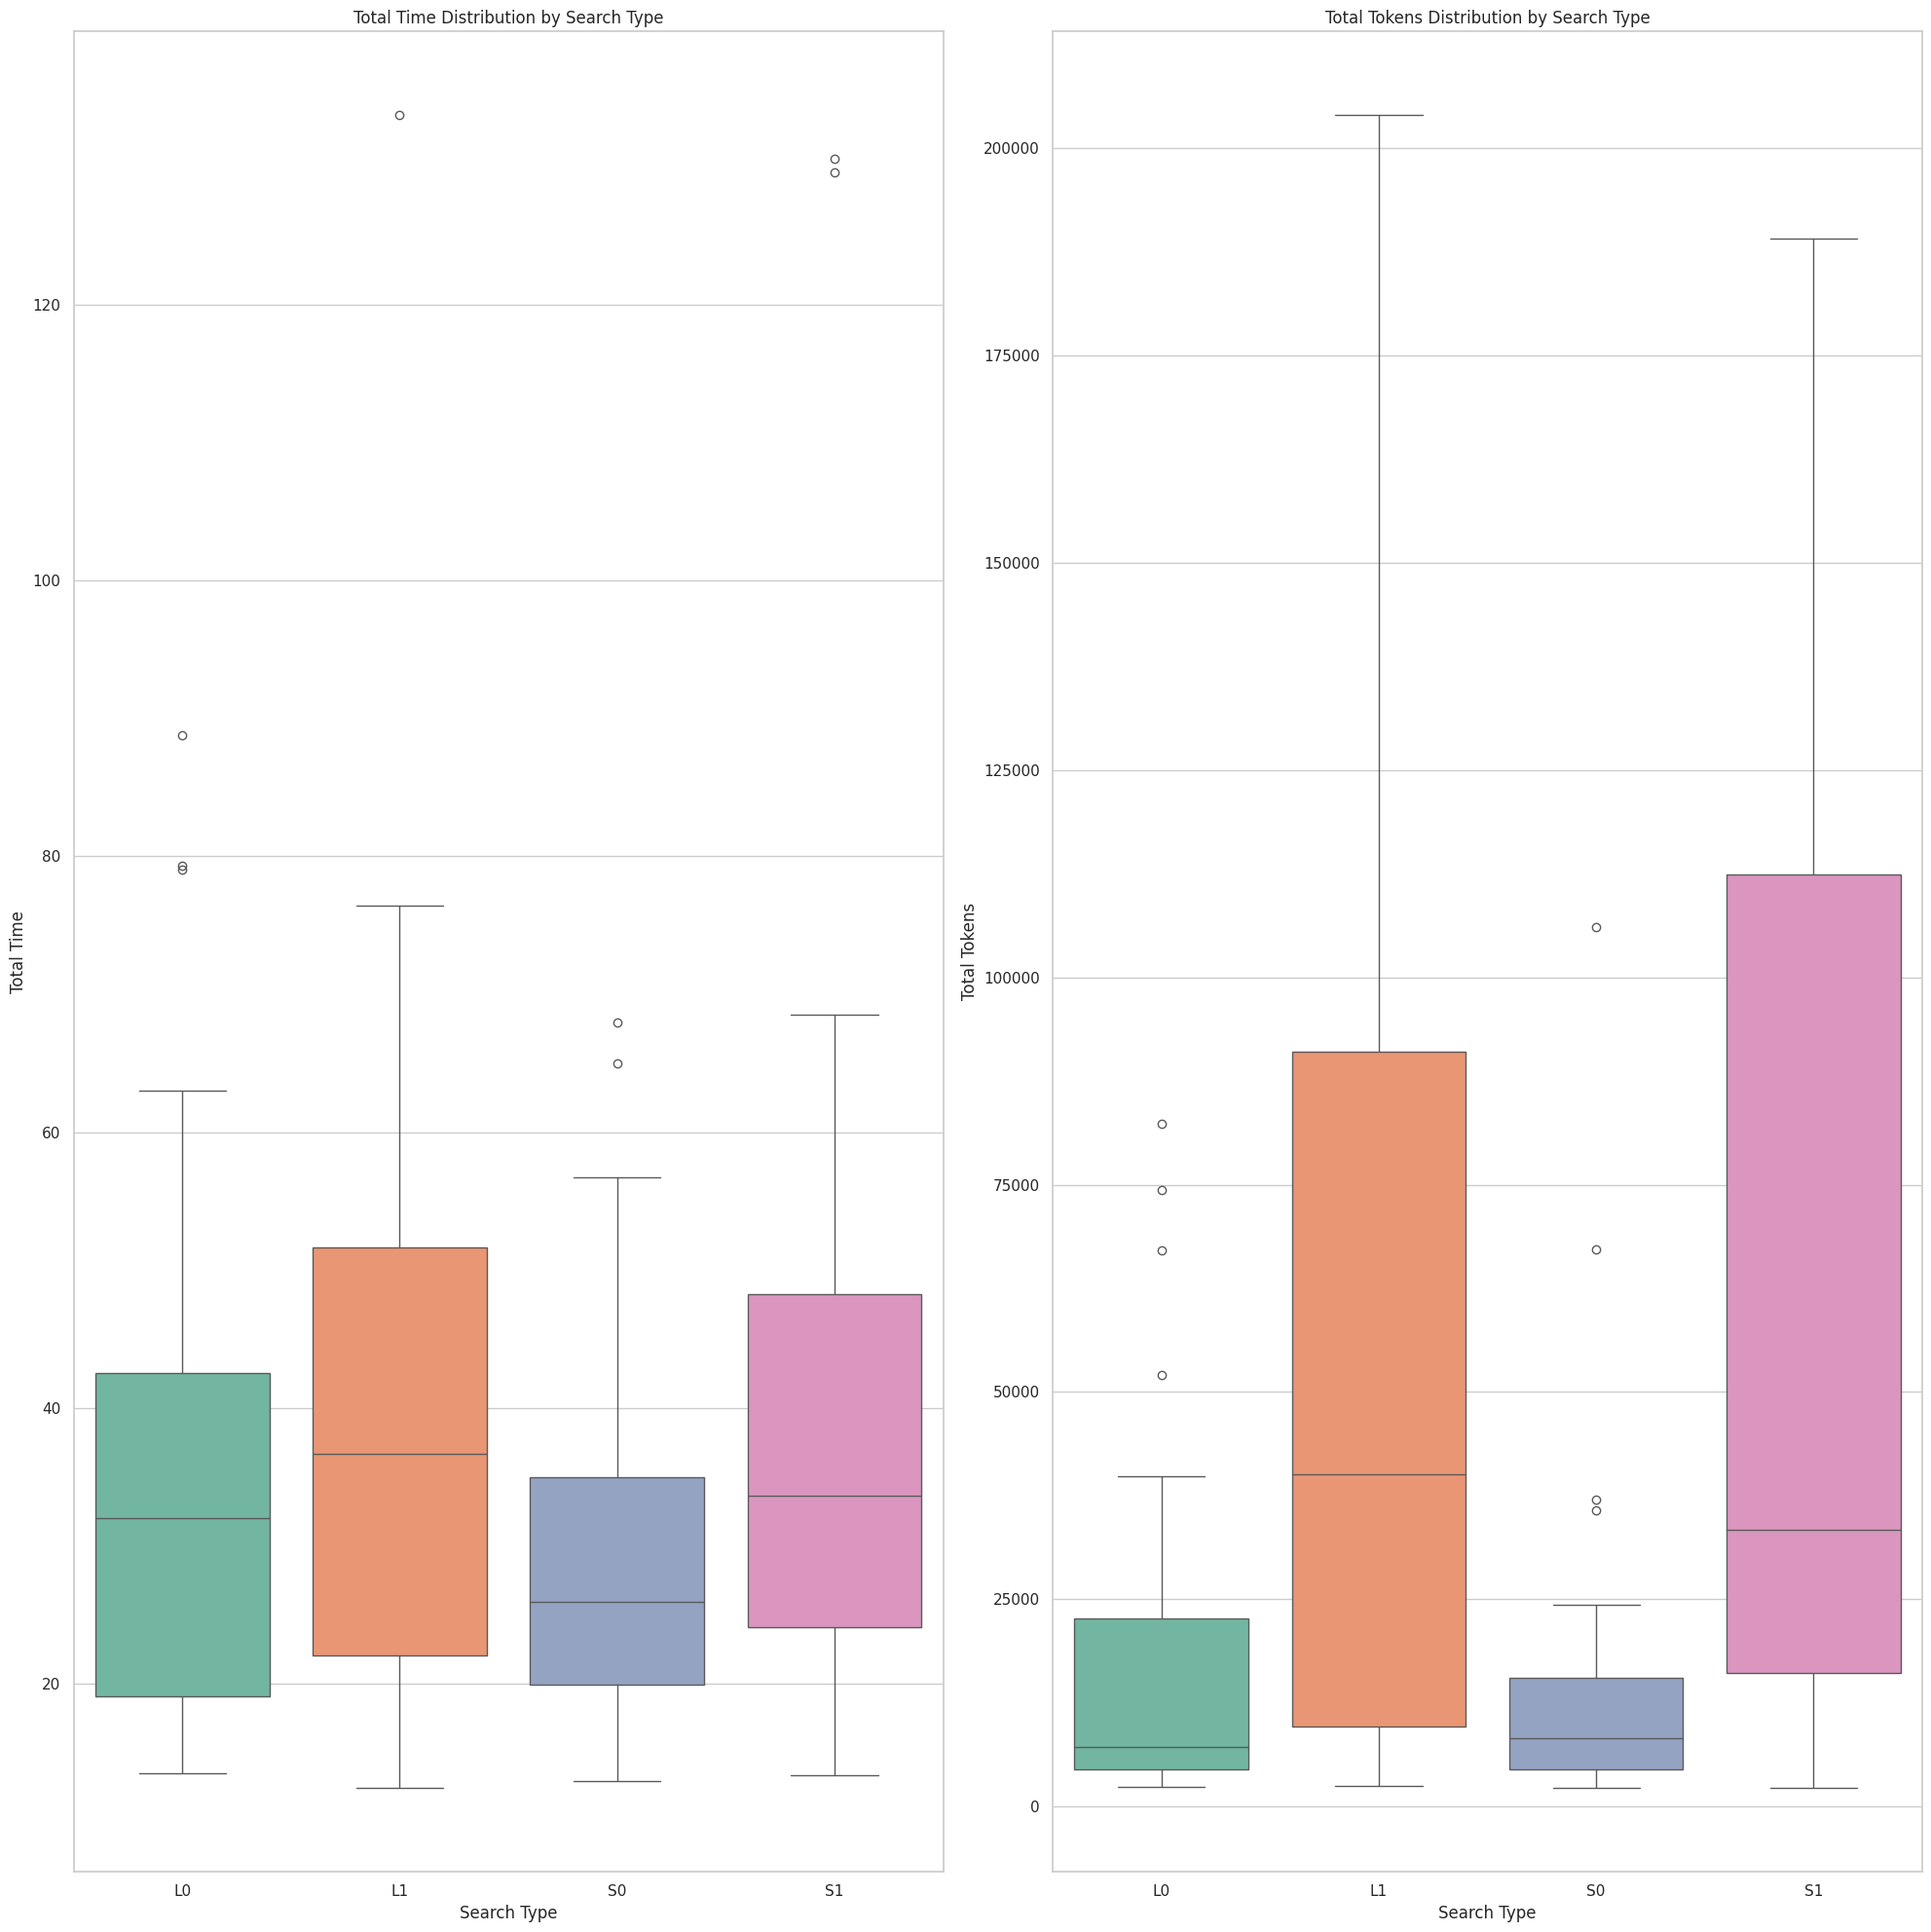

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

for model in set(df["model"].unique()):
    print("Boxplots for model: ", model)
    df_model = df[df["model"] == model]
    plt.figure(figsize=(20, 20))
    
    # Box plot for total_time
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_model, x="search_type", y="total_time", palette="Set2", legend=False)
    plt.title("Total Time Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Time")
    plt.tight_layout()
    # plt.xticks([])
    
    # Box plot for total_tokens
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_model, x="search_type", y="total_tokens", palette="Set2", legend=False)
    plt.title("Total Tokens Distribution by Search Type")
    plt.xlabel("Search Type")
    plt.ylabel("Total Tokens")
    # plt.legend(['Lexical Search', 'Similarity Search'], loc='upper center', bbox_to_anchor=(0.5, -0.05),
    #           fancybox=True, shadow=True, ncol=5)
    
    plt.tight_layout()
    
    plt.show()

/tmp/ipykernel_48537/122756833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df, x="search_type", y="total_time", palette="coolwarm")
/tmp/ipykernel_48537/122756833.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(data=df, x="search_type", y="total_tokens", palette="coolwarm")


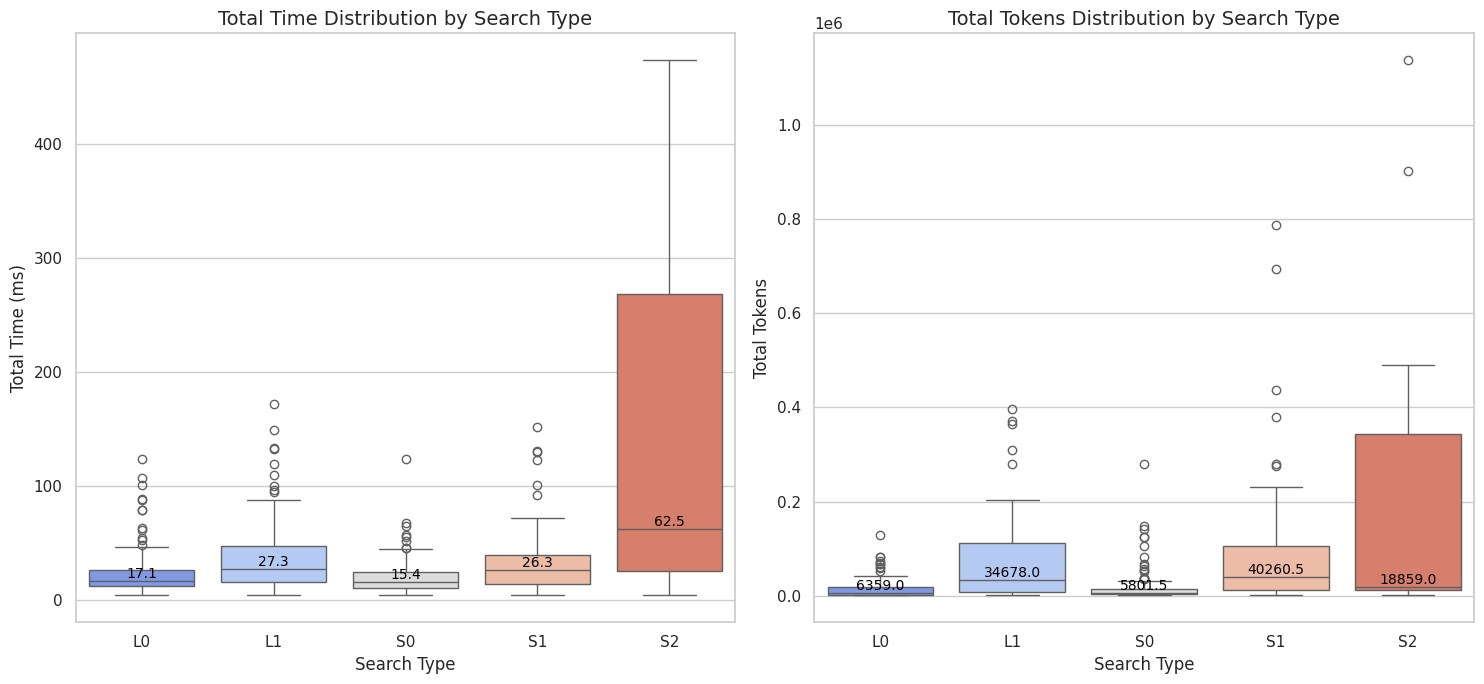

In [78]:
# Set general style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(15, 7))

# Box plot for total_time
plt.subplot(1, 2, 1)
ax1 = sns.boxplot(data=df, x="search_type", y="total_time", palette="coolwarm")
plt.title("Total Time Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Time (ms)", fontsize=12)

# Add median value annotations
medians_time = df.groupby("search_type")["total_time"].median().reset_index()
for idx, row in medians_time.iterrows():
    plt.text(
        x=idx,
        y=row["total_time"],
        s=f"{row['total_time']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Box plot for total_tokens
plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x="search_type", y="total_tokens", palette="coolwarm")
plt.title("Total Tokens Distribution by Search Type", fontsize=14)
plt.xlabel("Search Type", fontsize=12)
plt.ylabel("Total Tokens", fontsize=12)

# Add median value annotations
medians_tokens = df.groupby("search_type")["total_tokens"].median().reset_index()
for idx, row in medians_tokens.iterrows():
    plt.text(
        x=idx,
        y=row["total_tokens"],
        s=f"{row['total_tokens']:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [51]:
dict_map = {
    "lexical_search_0_hop": "L0",
    "lexical_search_1_hop": "L1",
    "lexical_search_2_hop": "S2",
    "similarity_search_0_hop": "S0",
    "similarity_search_1_hop": "S1",
}
df = df.replace({"search_type": dict_map})

In [52]:
df.head()

,consumer_id,model,search_type,question,total_time,total_tokens
209,Edythe31_Morar593_9c3df38a-d3b7-2198-3898-51f9...,gemini-1.5-pro,L0,Q3,13.671226,5968
250,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,gemini-1.5-pro,L0,Q2,4.058216,1001
249,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,gemini-1.5-pro,L0,Q3,10.718611,13260
248,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,gemini-1.5-pro,L0,Q8,10.636145,2900
293,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,gemini-1.5-pro,L0,Q4,6.905043,28119


In [53]:
set(df["model"].unique())

{'anthropic.claude-v3-opus', 'gemini-1.5-pro', 'gpt-4o-2024-08-06'}

/tmp/ipykernel_48537/3283576253.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", showfliers=True)
/tmp/ipykernel_48537/3283576253.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", showfliers=True)


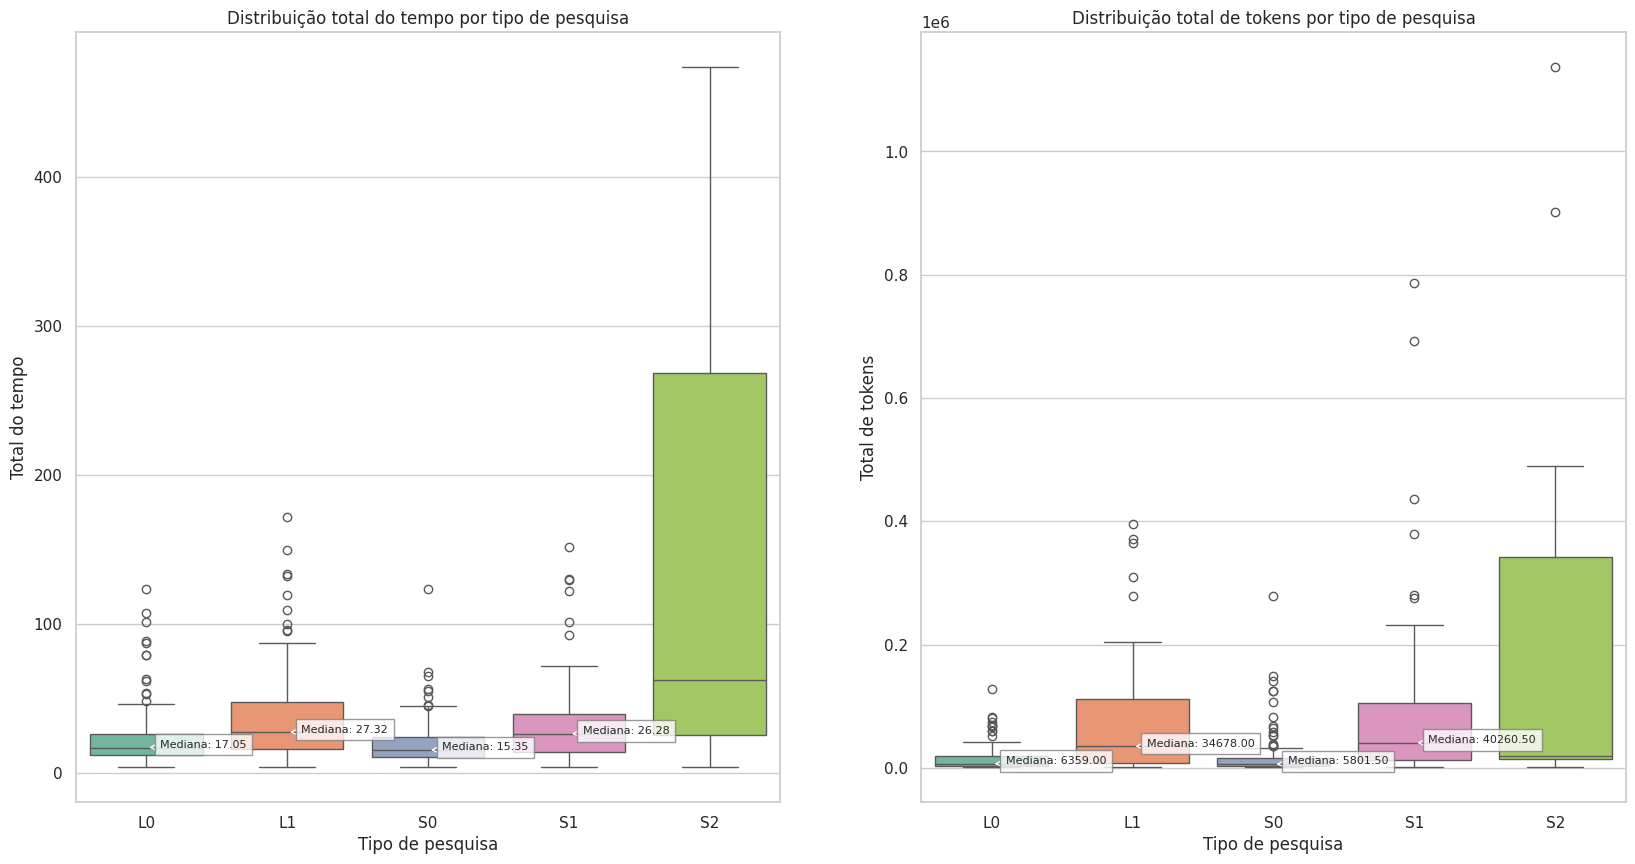

In [54]:
# Adjust the figure size for better layout
plt.figure(figsize=(20, 10))

# Box plot for total_time
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="search_type", y="total_time", palette="Set2", showfliers=True)
plt.title("Distribuição total do tempo por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total do tempo")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_time"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# Box plot for total_tokens
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="search_type", y="total_tokens", palette="Set2", showfliers=True)
plt.title("Distribuição total de tokens por tipo de pesquisa")
plt.xlabel("Tipo de pesquisa")
plt.ylabel("Total de tokens")
plt.xticks()

# Annotate the box plots with the median values
medians = df.groupby("search_type")["total_tokens"].median().values
median_coords = [
    (0, medians[0]),
    (1, medians[1]),
    (2, medians[2]),
    (3, medians[3]),
]
for x, y in median_coords:
    plt.annotate(
        f"Mediana: {y:.2f}",
        xy=(x, y),
        xytext=(x + 0.1, y),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

# Use a logarithmic scale for the y-axis
# plt.yscale('log')

# plt.tight_layout()
plt.show()